<a href="https://colab.research.google.com/github/marcinwolter/Varia/blob/main/lecture5_llm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>

# Introduction to Machine Learning
## Lecture 5
## **Large Language Models & the Attention Mechanism**

*Marcin Wolter, IFJ PAN — marcin.wolter@ifj.edu.pl*

*All materials: https://github.com/marcinwolter/MachineLearning-KISD-2026*

---
</center>

## Today's programme

| # | Topic |
|---|-------|
| 1 | From RNNs to Transformers — why attention was needed |
| 2 | The attention mechanism — how it works, step by step |
| 3 | Multi-head attention |
| 4 | The full Transformer architecture |
| 5 | From Transformer to GPT — Large Language Models |
| 6 | Hands-on: tokenisation, embeddings, and a tiny GPT |
| 7 | Using a pre-trained LLM with the HuggingFace library |

> **Prerequisites:** Parts 1–4 of this course (DNNs, CNNs). You should be comfortable with numpy arrays and Keras models.

<center>

---
---

# 🟢 Part 1: Why did we need a new architecture?

---
---
</center>

## 1.1  The problem with sequences

Images have a fixed grid structure — that is why CNNs work so well on them.
Text is different: it is a **variable-length sequence** where the meaning of each word depends on context that can be far away.

```
"The trophy didn't fit in the suitcase because it was too big."
```

What does *"it"* refer to — the trophy or the suitcase?  
A human resolves this by looking at *both* words simultaneously. Early neural networks could not do this efficiently.

## 1.2  Recurrent Neural Networks (RNNs)

RNNs process sequences one token at a time, maintaining a hidden state $h_t$:

$$h_t = f(h_{t-1},\, x_t)$$

<img src='https://upload.wikimedia.org/wikipedia/commons/b/b5/Recurrent_neural_network_unfold.svg' width=500>

**Problems:**
- **Vanishing gradients** — gradients shrink exponentially over long sequences; early tokens are forgotten
- **Sequential computation** — step $t$ cannot start until step $t-1$ finishes → slow on GPUs
- **Fixed-size bottleneck** — the entire sentence must be compressed into one hidden vector $h_T$

LSTMs and GRUs mitigate the gradient problem but do not solve the bottleneck or the speed issue.

## 1.3  The key idea: attention

Instead of compressing the whole sequence into one vector, what if every output position could **directly look at every input position**?

> *"Attention is All You Need"* — Vaswani et al., 2017

This single paper replaced recurrence entirely and became the foundation of every modern LLM.

<center>

---
---

# 🟢 Part 2: The Attention Mechanism

---
---
</center>

## 2.1  Intuition: a soft dictionary lookup

Imagine a Python dictionary:
```python
{"cat": "furry animal", "dog": "loyal animal", "fish": "aquatic animal"}
```
A *hard* lookup for `"cat"` returns exactly one value.

**Attention is a *soft* lookup** — given a query $Q$, it returns a *weighted average* of all values, where the weights depend on how well each key $K$ matches the query.

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}}\right) V$$

| Symbol | Meaning |
|--------|---------|
| $Q$ | Query — "what am I looking for?" |
| $K$ | Key — "what does each position offer?" |
| $V$ | Value — "what information do I actually retrieve?" |
| $d_k$ | Dimension of keys — used to keep dot products from growing too large |

## 2.2  Step-by-step in numpy

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

np.random.seed(42)

# ── tiny example: 4 tokens, embedding dimension = 8 ─────────────────────────
tokens = ["The", "cat", "sat", "mat"]
T = len(tokens)   # sequence length
d_model = 8       # embedding dimension
d_k = 4           # key/query dimension (often d_model // num_heads)

# Pretend these are learned embedding vectors for each token
X = np.random.randn(T, d_model)

# Learned projection matrices (W_Q, W_K, W_V) — normally trained, here random
W_Q = np.random.randn(d_model, d_k)
W_K = np.random.randn(d_model, d_k)
W_V = np.random.randn(d_model, d_k)

# Project inputs
Q = X @ W_Q   # (T, d_k)
K = X @ W_K   # (T, d_k)
V = X @ W_V   # (T, d_k)

print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)

Q shape: (4, 4)
K shape: (4, 4)
V shape: (4, 4)


In [22]:
# ── Step 1: raw attention scores ─────────────────────────────────────────────
scores = Q @ K.T / np.sqrt(d_k)   # (T, T)
print("Raw scores (before softmax):")
print(np.round(scores, 2))

Raw scores (before softmax):
[[ -0.53  -3.93   0.87   0.8 ]
 [  2.99   6.2   -9.33   5.66]
 [ -4.57   3.98   5.74  -1.12]
 [  6.39  -2.28 -10.85   1.32]]


In [23]:
# ── Step 2: softmax → attention weights ──────────────────────────────────────
def softmax(x, axis=-1):
    e = np.exp(x - x.max(axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)

weights = softmax(scores)   # (T, T)

print("Attention weights (each row sums to 1):")
print(np.round(weights, 3))
print("Row sums:", np.round(weights.sum(axis=1), 4))

Attention weights (each row sums to 1):
[[0.112 0.004 0.456 0.428]
 [0.025 0.616 0.    0.359]
 [0.    0.148 0.851 0.001]
 [0.994 0.    0.    0.006]]
Row sums: [1. 1. 1. 1.]


In [24]:
# ── Step 3: weighted sum of values ───────────────────────────────────────────
output = weights @ V   # (T, d_k)
print("Attention output shape:", output.shape)
print("Output (first token):", np.round(output[0], 3))

Attention output shape: (4, 4)
Output (first token): [-0.266  1.247 -1.711 -0.26 ]


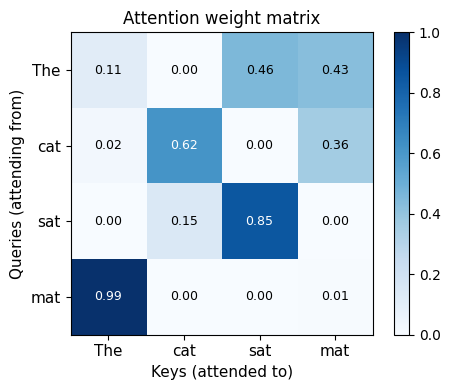

In [25]:
# ── Visualise the attention weight matrix ────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(weights, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(T)); ax.set_xticklabels(tokens, fontsize=11)
ax.set_yticks(range(T)); ax.set_yticklabels(tokens, fontsize=11)
ax.set_xlabel("Keys (attended to)", fontsize=11)
ax.set_ylabel("Queries (attending from)", fontsize=11)
ax.set_title("Attention weight matrix", fontsize=12)
plt.colorbar(im, ax=ax, fraction=0.046)
for i in range(T):
    for j in range(T):
        ax.text(j, i, f"{weights[i,j]:.2f}", ha='center', va='center',
                fontsize=9, color='white' if weights[i,j] > 0.5 else 'black')
plt.tight_layout()
plt.show()

> **Check ✏️**
> - Each *row* is the attention pattern for one query token. Which token attends most strongly to itself?
> - What does it mean when a token has high attention weight on a *different* token?
> - Why do we divide by $\sqrt{d_k}$? Try removing it and printing the raw scores — what happens to the softmax output?

## 2.3  Causal masking — preventing the future from leaking

In **encoder** models (e.g. BERT) every token can attend to every other token — this is fine for understanding tasks.

In **decoder** models (e.g. GPT) we are *generating* text left to right. Token at position $t$ must not look at positions $t+1, t+2, \ldots$ — that would be cheating.

We enforce this with a **causal mask**: set future positions to $-\infty$ before the softmax.

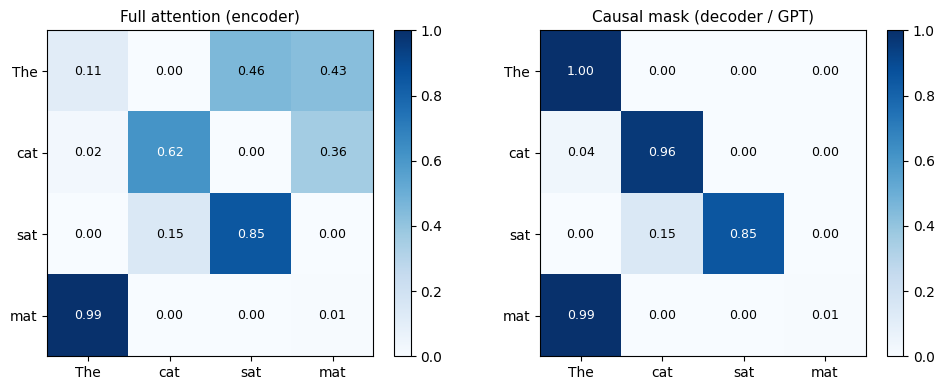

Causal weights — future positions are zero:
[[1.    0.    0.    0.   ]
 [0.039 0.961 0.    0.   ]
 [0.    0.148 0.852 0.   ]
 [0.994 0.    0.    0.006]]


In [26]:
# ── Causal mask ───────────────────────────────────────────────────────────────
mask = np.tril(np.ones((T, T)))          # lower triangular: 1 = allowed
mask_val = np.where(mask == 0, -1e9, 0)  # 0 = keep, -inf = block

masked_scores = scores + mask_val
causal_weights = softmax(masked_scores)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, w, title in zip(axes,
                         [weights, causal_weights],
                         ['Full attention (encoder)', 'Causal mask (decoder / GPT)']):
    im = ax.imshow(w, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(T)); ax.set_xticklabels(tokens, fontsize=10)
    ax.set_yticks(range(T)); ax.set_yticklabels(tokens, fontsize=10)
    ax.set_title(title, fontsize=11)
    for i in range(T):
        for j in range(T):
            ax.text(j, i, f"{w[i,j]:.2f}", ha='center', va='center',
                    fontsize=9, color='white' if w[i,j] > 0.5 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

print("Causal weights — future positions are zero:")
print(np.round(causal_weights, 3))

<center>

---
---

# 🟢 Part 3: Multi-Head Attention

---
---
</center>

## 3.1  Why multiple heads?

A single attention head learns one way of relating tokens.
With **multiple heads**, the model can simultaneously attend to:
- syntactic relationships (subject → verb)
- semantic relationships (pronoun → antecedent)
- positional relationships (nearby tokens)

Each head runs its own independent $Q, K, V$ projections, then the outputs are concatenated and projected back:

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)\, W^O$$

where $\text{head}_i = \text{Attention}(Q W_i^Q,\, K W_i^K,\, V W_i^V)$

In [27]:
def attention(Q, K, V, mask=None):
    """Scaled dot-product attention."""
    d_k = Q.shape[-1]
    scores = Q @ K.swapaxes(-2, -1) / np.sqrt(d_k)
    if mask is not None:
        scores += mask
    w = softmax(scores)
    return w @ V, w

def multihead_attention(X, num_heads, d_model, mask=None):
    """Minimal multi-head attention (numpy, no training)."""
    assert d_model % num_heads == 0
    d_k = d_model // num_heads
    T = X.shape[0]

    all_outputs = []
    all_weights = []
    for h in range(num_heads):
        Wq = np.random.randn(d_model, d_k) * 0.1
        Wk = np.random.randn(d_model, d_k) * 0.1
        Wv = np.random.randn(d_model, d_k) * 0.1
        Q_h = X @ Wq
        K_h = X @ Wk
        V_h = X @ Wv
        out_h, w_h = attention(Q_h, K_h, V_h, mask)
        all_outputs.append(out_h)
        all_weights.append(w_h)

    # Concatenate heads and project
    concat = np.concatenate(all_outputs, axis=-1)   # (T, d_model)
    W_O = np.random.randn(d_model, d_model) * 0.1
    return concat @ W_O, all_weights

np.random.seed(7)
d_model = 8
num_heads = 2
X = np.random.randn(T, d_model)

output_mha, head_weights = multihead_attention(X, num_heads, d_model)
print("Multi-head attention output shape:", output_mha.shape)

Multi-head attention output shape: (4, 8)


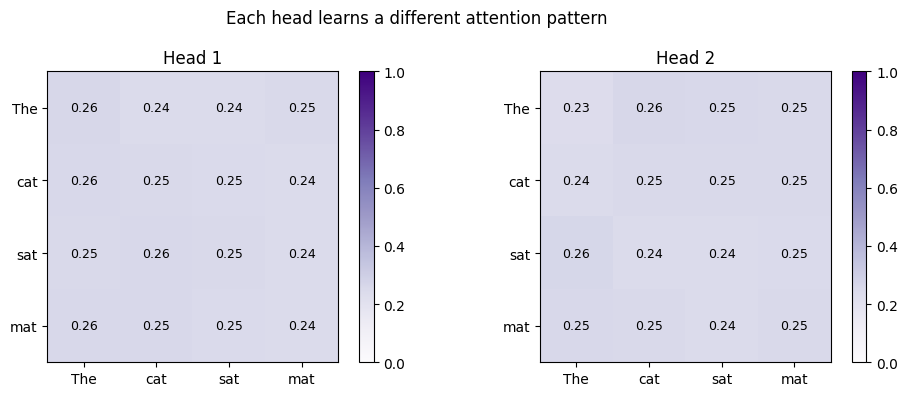

In [28]:
# ── Visualise each head's attention pattern ───────────────────────────────────
fig, axes = plt.subplots(1, num_heads, figsize=(5 * num_heads, 4))
for h, (ax, w) in enumerate(zip(axes, head_weights)):
    im = ax.imshow(w, cmap='Purples', vmin=0, vmax=1)
    ax.set_xticks(range(T)); ax.set_xticklabels(tokens, fontsize=10)
    ax.set_yticks(range(T)); ax.set_yticklabels(tokens, fontsize=10)
    ax.set_title(f"Head {h+1}", fontsize=12)
    for i in range(T):
        for j in range(T):
            ax.text(j, i, f"{w[i,j]:.2f}", ha='center', va='center',
                    fontsize=9, color='white' if w[i,j] > 0.5 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Each head learns a different attention pattern", fontsize=12)
plt.tight_layout()
plt.show()

> **Check ✏️**
> - Do the two heads produce the same pattern? Why or why not?
> - In GPT-4, there are 96 attention heads. What might each head specialise in?

<center>

---
---

# 🟢 Part 4: The Transformer Architecture

---
---
</center>

## 4.1  The full picture

A Transformer block adds three things around attention:

```
Input embeddings + Positional encoding
        │
┌───────▼──────────────────────────┐
│  Layer Norm                      │
│  Multi-Head Self-Attention       │◄── residual connection
│  + residual                      │
├──────────────────────────────────┤
│  Layer Norm                      │
│  Feed-Forward Network (2 layers) │◄── residual connection
│  + residual                      │
└───────────────────────────────────┘
        │
   (repeated N times)
        │
    Output
```

Key components:

| Component | Role |
|-----------|------|
| **Positional encoding** | Injects token order (attention is permutation-invariant) |
| **Layer normalisation** | Stabilises training (applied *before* each sub-layer) |
| **Residual connections** | Allow gradients to flow through deep stacks |
| **Feed-forward network** | Two Dense layers with ReLU — adds non-linearity per position |

## 4.2  Positional encoding

Attention has no built-in notion of order — `["cat", "sat", "the"]` would give the same weights as `["the", "cat", "sat"]`.

We add a **positional encoding** vector to each token embedding.
The original Transformer uses sinusoids of different frequencies:

$$PE_{(pos, 2i)} = \sin\!\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

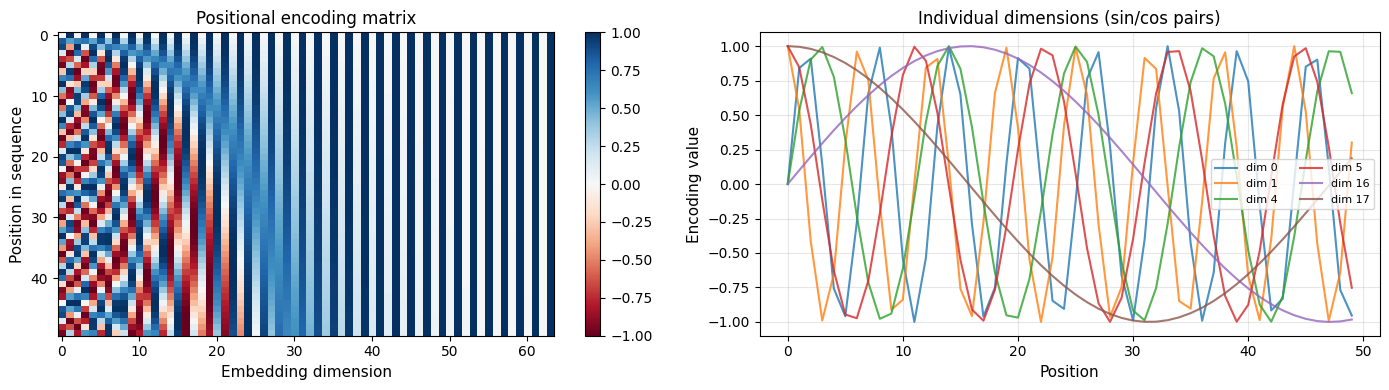

In [29]:
def positional_encoding(max_len, d_model):
    PE = np.zeros((max_len, d_model))
    pos = np.arange(max_len)[:, None]           # (max_len, 1)
    div = np.exp(np.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
    PE[:, 0::2] = np.sin(pos * div)
    PE[:, 1::2] = np.cos(pos * div)
    return PE

max_len, d_model = 50, 64
PE = positional_encoding(max_len, d_model)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

im = axes[0].imshow(PE, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
axes[0].set_xlabel("Embedding dimension", fontsize=11)
axes[0].set_ylabel("Position in sequence", fontsize=11)
axes[0].set_title("Positional encoding matrix", fontsize=12)
plt.colorbar(im, ax=axes[0])

for dim in [0, 1, 4, 5, 16, 17]:
    axes[1].plot(PE[:, dim], label=f"dim {dim}", alpha=0.8)
axes[1].set_xlabel("Position", fontsize=11)
axes[1].set_ylabel("Encoding value", fontsize=11)
axes[1].set_title("Individual dimensions (sin/cos pairs)", fontsize=12)
axes[1].legend(fontsize=8, ncol=2)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

> **Check ✏️**
> - Why do lower-index dimensions oscillate faster than higher-index ones?
> - Why are sinusoids a good choice? (Hint: think about what the model can learn about *relative* distances.)
> - Modern LLMs (GPT-4, LLaMA) use **Rotary Position Embedding (RoPE)** instead. What problem does it solve?

<center>

---
---

# 🟢 Part 5: From Transformer to Large Language Models

---
---
</center>

## 5.1  Language modelling

An LLM is trained on a deceptively simple task:

> **Given the previous tokens, predict the next token.**

$$P(w_t \mid w_1, w_2, \ldots, w_{t-1})$$

This is called **autoregressive language modelling**. At inference time, the model generates text by repeatedly sampling the next token and appending it to the sequence.

## 5.2  GPT architecture

GPT (Generative Pre-trained Transformer) is a **decoder-only** Transformer:

```
Input tokens  →  Token embedding + Positional encoding
                      │
              ┌───────▼──────────┐
              │  Transformer     │
              │  block × N       │  ← causal mask applied here
              └───────┬──────────┘
                      │
              Linear projection → vocabulary logits
                      │
                   Softmax → probability over next token
```

| Model | Layers | Heads | d_model | Parameters |
|-------|--------|-------|---------|------------|
| GPT-1 | 12 | 12 | 768 | 117M |
| GPT-2 | 48 | 25 | 1600 | 1.5B |
| GPT-3 | 96 | 96 | 12288 | 175B |
| GPT-4 | ~120* | ~96* | ~25600* | ~1.8T* |

*estimated — OpenAI has not published exact numbers*

## 5.3  Training: next-token prediction at scale

The training objective (cross-entropy loss) is the same as what you used for MNIST — just with a vocabulary of ~50 000 tokens instead of 10 classes:

$$\mathcal{L} = -\frac{1}{T}\sum_{t=1}^{T} \log P(w_t \mid w_1, \ldots, w_{t-1})$$

What makes LLMs powerful is not the objective — it is the **scale**: trillions of tokens, billions of parameters, thousands of GPUs.

<center>

---
---

# 🟢 Part 6: Hands-on — Tokenisation, Embeddings & a Tiny GPT

---
---
</center>

## 6.1  What is a token?

LLMs do not process characters or words — they process **tokens**: subword units produced by algorithms like BPE (Byte-Pair Encoding).

```
"unhappiness"  →  ["un", "happ", "iness"]
"ChatGPT"      →  ["Chat", "G", "PT"]
"2026"         →  ["2026"]          (common numbers are one token)
```

Tokens allow the vocabulary to stay small (~50 000) while handling any word, including rare ones and new proper nouns.

In [30]:
# Install the tiktoken library (OpenAI's fast tokeniser, used by GPT-2/3/4)
# In Colab this takes ~10 seconds
!pip install tiktoken -q

import tiktoken

enc = tiktoken.get_encoding("gpt2")   # GPT-2 vocabulary, 50 257 tokens

examples = [
    "Hello world!",
    "The attention mechanism is the key innovation.",
    "unhappiness",
    "ChatGPT",
    "Kraków 2026",
    "x_train.reshape(60000, 784)",
]

print(f"{'Text':<45} {'Tokens':>7}  Token IDs")
print("─" * 80)
for text in examples:
    ids = enc.encode(text)
    decoded = [enc.decode([i]) for i in ids]
    print(f"{text:<45} {len(ids):>7}  {decoded}")

Text                                           Tokens  Token IDs
────────────────────────────────────────────────────────────────────────────────
Hello world!                                        3  ['Hello', ' world', '!']
The attention mechanism is the key innovation.       8  ['The', ' attention', ' mechanism', ' is', ' the', ' key', ' innovation', '.']
unhappiness                                         3  ['un', 'h', 'appiness']
ChatGPT                                             3  ['Chat', 'G', 'PT']
Kraków 2026                                         6  ['K', 'rak', 'ó', 'w', ' 20', '26']
x_train.reshape(60000, 784)                        13  ['x', '_', 'train', '.', 'resh', 'ape', '(', '6', '0000', ',', ' 7', '84', ')']


In [31]:
# ── Visualise token boundaries in a longer sentence ──────────────────────────
sentence = "Large language models are trained on next-token prediction at massive scale."
ids = enc.encode(sentence)
pieces = [enc.decode([i]) for i in ids]

print(f"Original : {sentence}")
print(f"Num tokens: {len(ids)}")
print()
print("Tokens:")
colors = ['[44m', '[42m', '[43m', '[41m', '[45m', '[46m']
reset = '[0m'
highlighted = ""
for i, piece in enumerate(pieces):
    highlighted += colors[i % len(colors)] + piece + reset
print(highlighted)

Original : Large language models are trained on next-token prediction at massive scale.
Num tokens: 14

Tokens:
Large language models are trained on next-token prediction at massive scale.


## 6.2  Word embeddings

Each token is mapped to a dense vector (the **embedding**). These vectors are learned during training and encode semantic meaning — similar words end up close together in the embedding space.

The famous example: $\vec{king} - \vec{man} + \vec{woman} \approx \vec{queen}$

In [32]:
# ── Explore embeddings with a pre-trained small model ────────────────────────
!pip install gensim -q

from gensim.downloader import load as gensim_load
import warnings; warnings.filterwarnings('ignore')

print("Downloading GloVe-50 embeddings (~70MB)...")
glove = gensim_load("glove-wiki-gigaword-50")
print(f"Vocabulary size: {len(glove):,}  |  Embedding dimension: {glove.vector_size}")

Vocabulary size: 400,000  |  Embedding dimension: 50


In [33]:
# ── Word arithmetic ───────────────────────────────────────────────────────────
print("king - man + woman =")
result = glove.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)
for word, score in result:
    print(f"  {word:<15} {score:.3f}")

print()
print("Paris - France + Poland =")
result = glove.most_similar(positive=['paris', 'poland'], negative=['france'], topn=5)
for word, score in result:
    print(f"  {word:<15} {score:.3f}")

print()
print("Most similar to 'neural':")
for word, score in glove.most_similar('neural', topn=6):
    print(f"  {word:<15} {score:.3f}")

king - man + woman =
  queen           0.852
  throne          0.766
  prince          0.759
  daughter        0.747
  elizabeth       0.746

Paris - France + Poland =
  warsaw          0.913
  prague          0.839
  budapest        0.796
  berlin          0.781
  stockholm       0.770

Most similar to 'neural':
  neuronal        0.845
  differentiation 0.805
  neurons         0.782
  pathways        0.781
  plasticity      0.779
  synapses        0.757


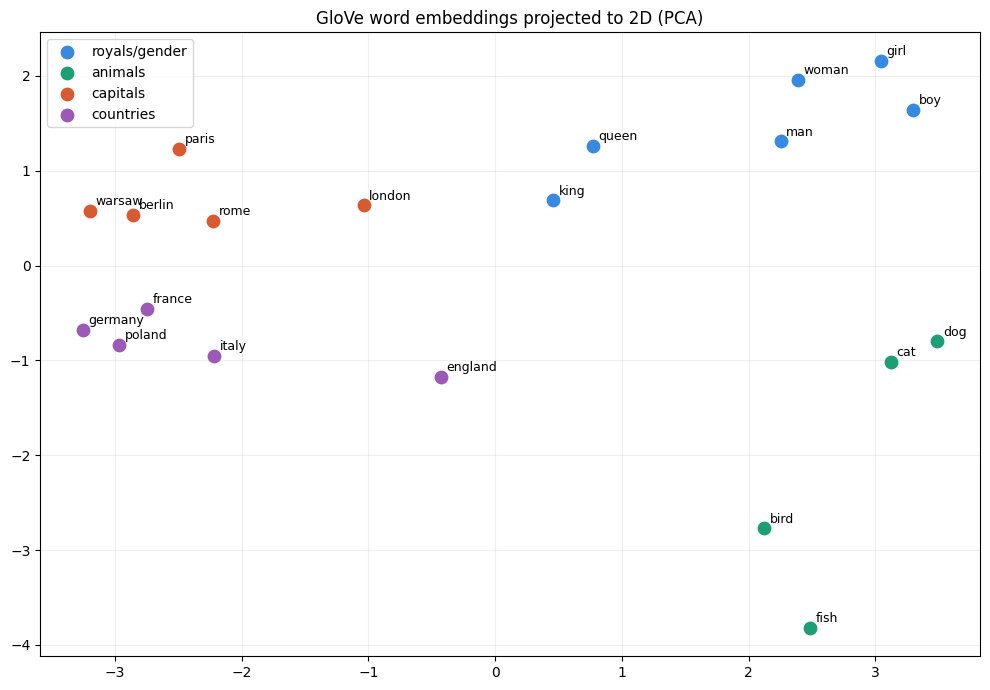

Variance explained by 2 PCA components: 51.7%


In [34]:
# ── Visualise embeddings with PCA ─────────────────────────────────────────────
from sklearn.decomposition import PCA

words = ['king', 'queen', 'man', 'woman', 'boy', 'girl',
         'dog', 'cat', 'fish', 'bird',
         'paris', 'london', 'berlin', 'warsaw', 'rome',
         'france', 'england', 'germany', 'poland', 'italy']

vectors = np.array([glove[w] for w in words])
pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

groups = {'royals/gender': words[:6], 'animals': words[6:10],
          'capitals': words[10:15], 'countries': words[15:]}
group_colors = {'royals/gender': '#378ADD', 'animals': '#1D9E75',
                'capitals': '#D85A30', 'countries': '#9C59B6'}

fig, ax = plt.subplots(figsize=(10, 7))
for group, members in groups.items():
    idxs = [words.index(w) for w in members]
    ax.scatter(coords[idxs, 0], coords[idxs, 1],
               c=group_colors[group], label=group, s=80, zorder=3)
for i, word in enumerate(words):
    ax.annotate(word, coords[i], fontsize=9,
                xytext=(4, 4), textcoords='offset points')

ax.set_title("GloVe word embeddings projected to 2D (PCA)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Variance explained by 2 PCA components: "
      f"{pca.explained_variance_ratio_.sum()*100:.1f}%")

> **Check ✏️**
> - Do capital cities cluster together? Do countries?
> - Find a word pair where the analogy *word_A - word_B + word_C* gives a surprising result.
> - GloVe embeddings are **static** — the same word always gets the same vector. How is this a problem for words like *"bank"* (river bank vs. financial bank)?

## 6.3  Build a tiny GPT in Keras

We will train a character-level language model on a small text.
This is not a *real* LLM — it has ~200K parameters and trains in minutes — but it demonstrates every component of the GPT architecture.

In [44]:
import tensorflow as tf
from tensorflow import keras
from keras import layers

# ── Download a short text to train on ─────────────────────────────────────────
import urllib.request
url = "https://www.gutenberg.org/files/1342/1342-0.txt"   # Pride and Prejudice
urllib.request.urlretrieve(url, "pride.txt")

with open("pride.txt", encoding="utf-8") as f:
    text = f.read()

#print(text)

# Keep only the story (skip Project Gutenberg header/footer)
start = text.find("Their sister’s wedding-day arrived")
end   = text.rfind("Derbyshire, had been the means of uniting them.")
text  = text[start:end+7]

print(start, end)

print(f"Text length : {len(text):,} characters")
print(f"First 200 chars:\n{text[:200]}")

593047 728474
Text length : 135,434 characters
First 200 chars:
Their sister’s wedding-day arrived; and Jane and Elizabeth felt for her
probably more than she felt for herself. The carriage was sent to meet
them at----, and they were to return in it by dinnertime.


In [45]:
# ── Character-level vocabulary ───────────────────────────────────────────────
print(f"Content of 'text' before vocab calculation: {text[:500]}...")
chars = sorted(set(text))
vocab_size = len(chars)
char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for c, i in char2idx.items()}

print(f"Vocabulary size: {vocab_size} unique characters")
print(f"Characters: {''.join(chars[:40])}...")

# Encode entire text as integers
data = np.array([char2idx[c] for c in text], dtype=np.int32)
print(f"\nEncoded length: {len(data):,} tokens")
print(f"First 30 tokens: {data[:30]}")

Content of 'text' before vocab calculation: Their sister’s wedding-day arrived; and Jane and Elizabeth felt for her
probably more than she felt for herself. The carriage was sent to meet
them at----, and they were to return in it by dinnertime. Their arrival
was dreaded by the elder Miss Bennets--and Jane more especially, who
gave Lydia the feelings which would have attended herself, had _she_
been the culprit, and was wretched in the thought of what her sister
must endure.

They came. The family were assembled in the breakfast-room to re...
Vocabulary size: 78 unique characters
Characters: 
 !()*,-./14689:;?ABCDEFGHIJKLMNOPRSTUVW...

Encoded length: 135,434 tokens
First 30 tokens: [36 53 50 54 63  1 64 54 64 65 50 63 75 64  1 68 50 49 49 54 59 52  7 49
 46 70  1 46 63 63]


In [46]:
# ── Create training sequences ─────────────────────────────────────────────────
SEQ_LEN   = 64     # context length
BATCH_SIZE = 64
EMBED_DIM  = 64    # embedding / d_model
NUM_HEADS  = 4
FF_DIM     = 128   # feed-forward hidden size
NUM_LAYERS = 2     # number of Transformer blocks
DROPOUT    = 0.1

def make_dataset(data, seq_len, batch_size):
    ds = tf.data.Dataset.from_tensor_slices(data)
    ds = ds.window(seq_len + 1, shift=1, drop_remainder=True)
    ds = ds.flat_map(lambda w: w.batch(seq_len + 1))
    ds = ds.map(lambda x: (x[:-1], x[1:]))   # input, target (shifted by 1)
    ds = ds.shuffle(10000).batch(batch_size, drop_remainder=True)
    return ds.prefetch(tf.data.AUTOTUNE)

dataset = make_dataset(data, SEQ_LEN, BATCH_SIZE)
print(f"Dataset created — one batch shape: input {BATCH_SIZE}×{SEQ_LEN}, target {BATCH_SIZE}×{SEQ_LEN}")

Dataset created — one batch shape: input 64×64, target 64×64


In [47]:
# ── Transformer block ─────────────────────────────────────────────────────────
def transformer_block(x, embed_dim, num_heads, ff_dim, dropout):
    # Multi-head self-attention with causal mask
    attn = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_dim // num_heads,
        dropout=dropout
    )(x, x, use_causal_mask=True)
    x = layers.LayerNormalization()(x + attn)

    # Feed-forward network
    ff = layers.Dense(ff_dim, activation='relu')(x)
    ff = layers.Dropout(dropout)(ff)
    ff = layers.Dense(embed_dim)(ff)
    x = layers.LayerNormalization()(x + ff)
    return x

# ── Build the tiny GPT ────────────────────────────────────────────────────────
inputs = keras.Input(shape=(SEQ_LEN,), dtype='int32')

# Token embedding + positional embedding (learned, not sinusoidal)
tok_emb = layers.Embedding(vocab_size, EMBED_DIM)(inputs)
pos_emb = layers.Embedding(SEQ_LEN,   EMBED_DIM)(tf.range(SEQ_LEN))
x = tok_emb + pos_emb
x = layers.Dropout(DROPOUT)(x)

for _ in range(NUM_LAYERS):
    x = transformer_block(x, EMBED_DIM, NUM_HEADS, FF_DIM, DROPOUT)

outputs = layers.Dense(vocab_size)(x)   # logits over vocabulary

model = keras.Model(inputs, outputs)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 64, 64)    │      4,992 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 64, 64)    │          0 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 64, 64)    │          0 │ add_10[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     16,640 │ dropout_10[0][0], │
│ (MultiHeadAttentio… │                   │            │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 64, 64)    │          0 │ dropout_10[0][0], │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_11[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 64, 128)   │          0 │ dense_8[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64, 64)    │      8,256 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 64, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_12[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 64, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_13[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 64, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 64, 128)   │          0 │ dense_10[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64, 64)    │      8,256 │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 77,006 (300.80 KB)

 Trainable params: 77,006 (300.80 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# ── Train ─────────────────────────────────────────────────────────────────────
# The model won't write Shakespeare but it will learn English structure

from keras.callbacks import EarlyStopping

history = model.fit(
    dataset,
    epochs=3,
    callbacks=[EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)],
    verbose=1
)

Epoch 1/3
2115/2115 ━━━━━━━━━━━━━━━━━━━━ 433s 202ms/step - accuracy: 0.5012 - loss: 1.6037
Epoch 2/3
2115/2115 ━━━━━━━━━━━━━━━━━━━━ 424s 200ms/step - accuracy: 0.5042 - loss: 1.5942
Epoch 3/3
2115/2115 ━━━━━━━━━━━━━━━━━━━━ 431s 202ms/step - accuracy: 0.5066 - loss: 1.5849


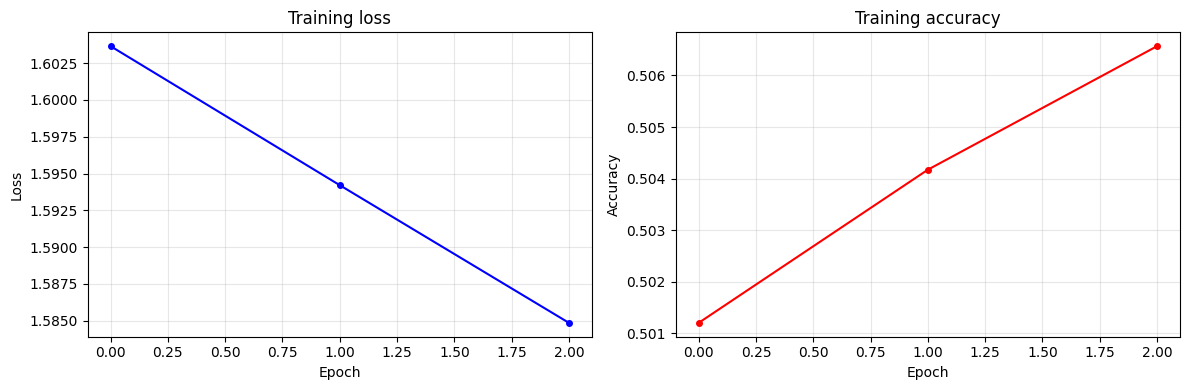

In [50]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
n = len(history.history['loss'])
ax1.plot(history.history['loss'], 'b-o', ms=4); ax1.set(xlabel='Epoch', ylabel='Loss', title='Training loss'); ax1.grid(alpha=0.3)
ax2.plot(history.history['accuracy'], 'r-o', ms=4); ax2.set(xlabel='Epoch', ylabel='Accuracy', title='Training accuracy'); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [51]:
# ── Text generation: temperature sampling ────────────────────────────────────
def generate(model, prompt, num_chars=300, temperature=1.0):
    """
    Generate text autoregressively.
    temperature < 1 → more conservative/repetitive
    temperature > 1 → more creative/random
    """
    result = list(prompt)
    for _ in range(num_chars):
        # Encode current context (last SEQ_LEN chars)
        context = result[-SEQ_LEN:]
        x = np.array([[char2idx.get(c, 0) for c in context]])
        x = np.pad(x, [(0,0),(SEQ_LEN - x.shape[1], 0)])  # left-pad if short

        logits = model.predict(x, verbose=0)[0, -1]        # last position
        logits = logits / temperature
        probs  = tf.nn.softmax(logits).numpy()
        next_char = np.random.choice(len(chars), p=probs)
        result.append(idx2char[next_char])

    return ''.join(result)

prompt = "It is a truth universally acknowledged"

print("─"*60)
print("Temperature = 0.5 (conservative):")
print(generate(model, prompt, temperature=0.5))
print()
print("─"*60)
print("Temperature = 1.0 (balanced):")
print(generate(model, prompt, temperature=1.0))
print()
print("─"*60)
print("Temperature = 1.5 (creative/chaotic):")
print(generate(model, prompt, temperature=1.5))

────────────────────────────────────────────────────────────
Temperature = 0.5 (conservative):
It is a truth universally acknowledged her reptined it from any with thim be asoncesion his from her of her fance her could not alll her athe was as not was by much
her happpy, and without her all the ben as he her be
her conded as welll as he do the could not produced and Elizabeth was as so all that her could by her than her all the c

────────────────────────────────────────────────────────────
Temperature = 1.0 (balanced):
It is a truth universally acknowledged approfer Elizabeth beegan clall your grearite of husband so to sin that
began, their was oung not of respion at Pembley afft spie to f your the gremore
isley with him adered her intermatter own gooing which apiner to goo meanne,
indiferems. I could not casincended marriage ther would not to acccnou

────────────────────────────────────────────────────────────
Temperature = 1.5 (creative/chaotic):
It is a truth universally acknowled

> **Check ✏️ — Temperature**
> - At temperature 0.5, does the text look more or less like English than at 1.5?
> - What happens as temperature → 0? What happens as temperature → ∞?
> - Real LLMs use **top-k** and **top-p (nucleus)** sampling instead of raw temperature. Why?

<center>

---
---

# 🟢 Part 7: Using Pre-trained LLMs with HuggingFace

---
---
</center>

## 7.1  The HuggingFace ecosystem

Training LLMs from scratch requires millions of GPU-hours. In practice, we use **pre-trained models** and either:

| Approach | When to use |
|----------|-------------|
| **Zero-shot** | No examples — just ask the model |
| **Few-shot** | A few examples in the prompt |
| **Fine-tuning** | Train all weights on domain data (~expensive) |
| **LoRA / PEFT** | Train a tiny adapter — most practical option |

The [HuggingFace Hub](https://huggingface.co/models) hosts >500 000 models.
The `transformers` library gives a unified API.

In [52]:
!pip install transformers -q

from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM
import warnings; warnings.filterwarnings('ignore')

## 7.2  Text generation with GPT-2

In [53]:
# GPT-2 small (117M parameters) — downloads ~500MB, runs on CPU
generator = pipeline("text-generation", model="gpt2", device=-1)

prompts = [
    "The attention mechanism works by",
    "Deep neural networks are similar to the human brain because",
    "The most important thing about large language models is",
]

for prompt in prompts:
    result = generator(
        prompt,
        max_new_tokens=60,
        do_sample=True,
        temperature=0.8,
        pad_token_id=50256
    )
    print(f"Prompt : {prompt}")
    print(f"GPT-2  : {result[0]['generated_text']}")
    print()

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'temperature', 'pad_token_id', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Prompt : The attention mechanism works by
GPT-2  : The attention mechanism works by pulling the heart muscle through the lower back and by pumping a heart pump through the lower abdomen.

By working at the core of the muscle, the muscles are able to keep the blood flowing. The heart muscle then pumps out more blood into the body.

When it is unable to pump



Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Prompt : Deep neural networks are similar to the human brain because
GPT-2  : Deep neural networks are similar to the human brain because it is so similar in size and complexity.

The only difference between the two approaches is that neural networks need to be tuned down to respond quickly. This is why, at every stage in the neural network's evolution, a significant part of the network's learning takes place in two separate timesc

Prompt : The most important thing about large language models is
GPT-2  : The most important thing about large language models is that they are an extremely difficult thing to model. What is important to understand is that they are not just a set of rules that define a set of behaviors but are also a way to define these behaviors.

There are three basic kinds of large language models.

Standard model:





## 7.3  Inspect the tokeniser

In [54]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")

sentences = [
    "Artificial intelligence is transforming science.",
    "Sztuczna inteligencja zmienia naukę.",   # Polish
    "def softmax(x): return np.exp(x) / np.exp(x).sum()",
]

print(f"{'Text':<55} {'#tokens':>7}")
print("─"*70)
for s in sentences:
    ids = tokenizer.encode(s)
    pieces = tokenizer.convert_ids_to_tokens(ids)
    print(f"{s[:54]:<55} {len(ids):>7}")
    print(f"  Tokens: {pieces}")
    print()

Text                                                    #tokens
──────────────────────────────────────────────────────────────────────
Artificial intelligence is transforming science.              7
  Tokens: ['Art', 'ificial', 'Ġintelligence', 'Ġis', 'Ġtransforming', 'Ġscience', '.']

Sztuczna inteligencja zmienia naukę.                         20
  Tokens: ['S', 'z', 't', 'uc', 'z', 'na', 'Ġintel', 'igen', 'c', 'ja', 'Ġz', 'm', 'ien', 'ia', 'Ġn', 'au', 'k', 'Ä', 'Ļ', '.']

def softmax(x): return np.exp(x) / np.exp(x).sum()           22
  Tokens: ['def', 'Ġsoft', 'max', '(', 'x', '):', 'Ġreturn', 'Ġnp', '.', 'exp', '(', 'x', ')', 'Ġ/', 'Ġnp', '.', 'exp', '(', 'x', ').', 'sum', '()']



## 7.4  Visualise self-attention in a real model

In [55]:
# BertViz lets us inspect attention weights of real models
!pip install bertviz -q

from transformers import BertTokenizer, BertModel
from bertviz import head_view

bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model     = BertModel.from_pretrained('bert-base-uncased', output_attentions=True)

sentence = "The trophy didn't fit in the suitcase because it was too big."
inputs = bert_tokenizer(sentence, return_tensors='pt')
outputs = bert_model(**inputs)

tokens = bert_tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
attention = outputs.attentions  # tuple of (batch, heads, seq, seq) per layer

print(f"Sentence : {sentence}")
print(f"Tokens   : {tokens}")
print(f"Layers   : {len(attention)}")
print(f"Per layer: batch={attention[0].shape[0]}, heads={attention[0].shape[1]}, seq={attention[0].shape[2]}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.1 MB/s eta 0:00:00


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sentence : The trophy didn't fit in the suitcase because it was too big.
Tokens   : ['[CLS]', 'the', 'trophy', 'didn', "'", 't', 'fit', 'in', 'the', 'suitcase', 'because', 'it', 'was', 'too', 'big', '.', '[SEP]']
Layers   : 12
Per layer: batch=1, heads=12, seq=17


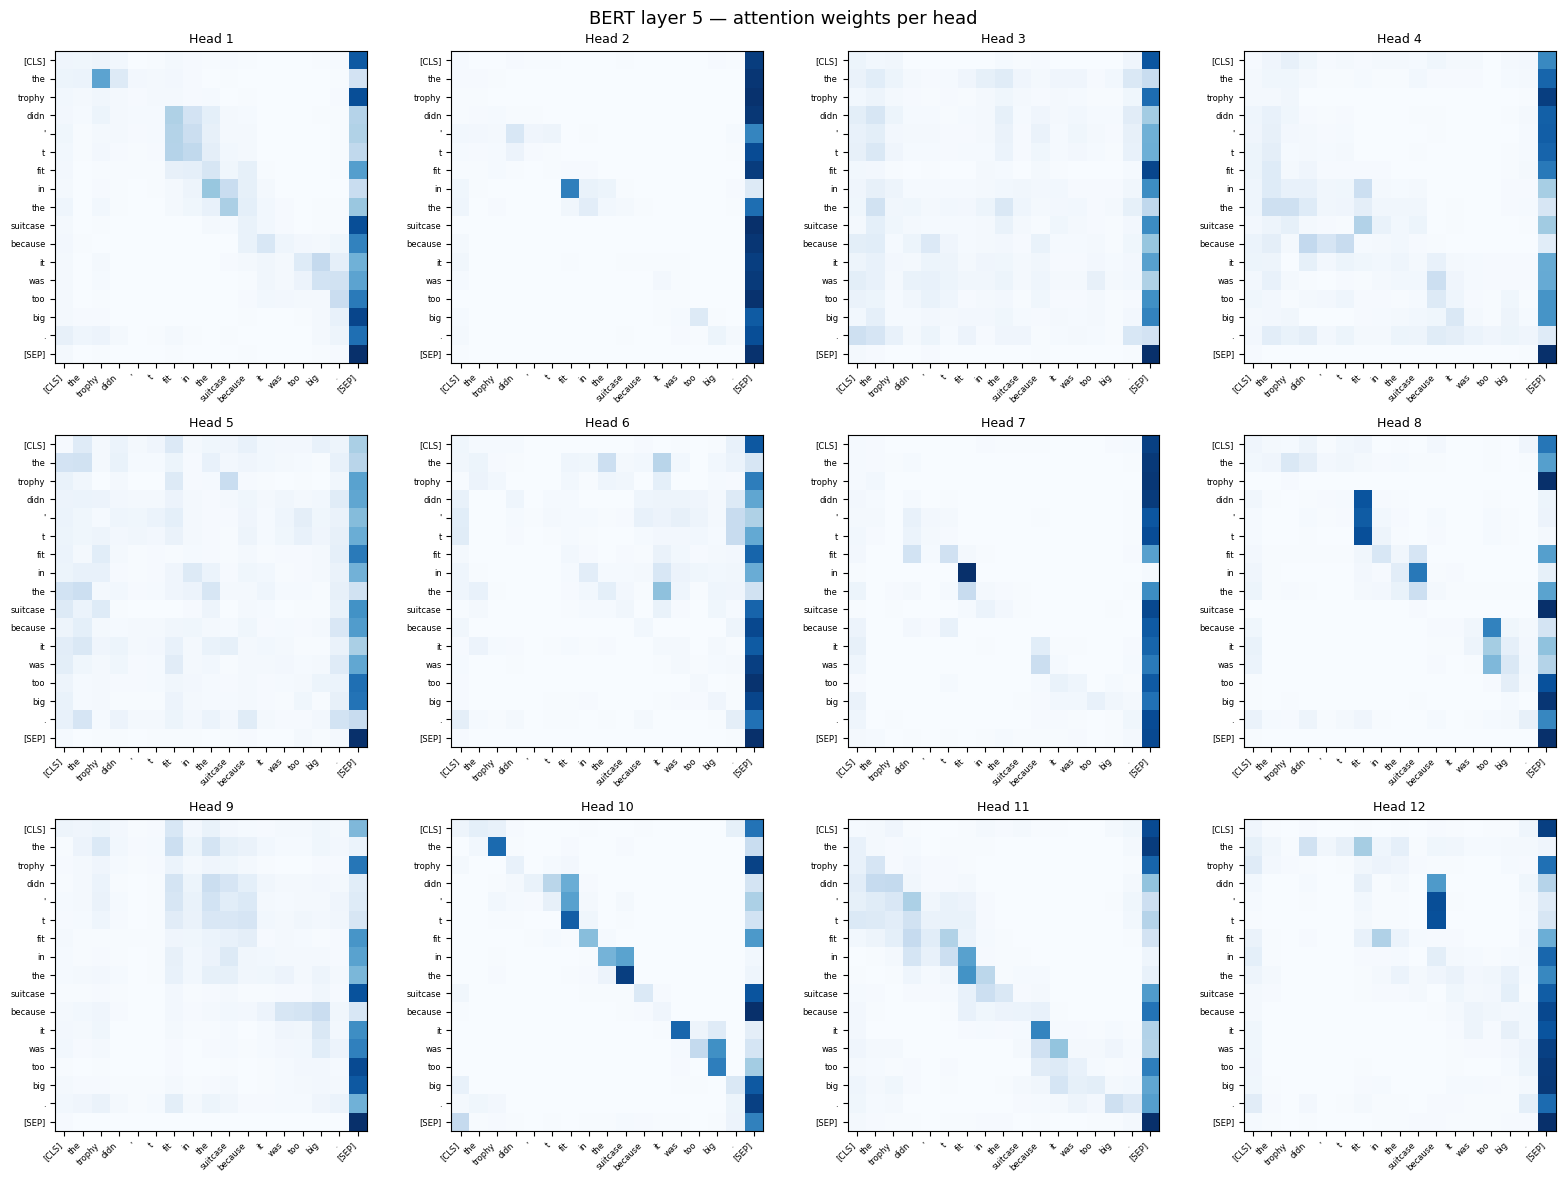

In [56]:
# ── Plot attention weights for one layer and all heads ────────────────────────
import torch

layer_idx = 5   # try layers 0, 5, 11

attn_layer = attention[layer_idx][0].detach().numpy()  # (heads, seq, seq)
num_heads_bert = attn_layer.shape[0]
T_bert = len(tokens)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle(f"BERT layer {layer_idx} — attention weights per head", fontsize=13)

for h, ax in enumerate(axes.flat):
    if h >= num_heads_bert:
        ax.axis('off'); continue
    im = ax.imshow(attn_layer[h], cmap='Blues', vmin=0, vmax=attn_layer[h].max())
    ax.set_xticks(range(T_bert))
    ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=6)
    ax.set_yticks(range(T_bert))
    ax.set_yticklabels(tokens, fontsize=6)
    ax.set_title(f"Head {h+1}", fontsize=9)

plt.tight_layout()
plt.show()

In [57]:
# ── Which token does 'it' attend to most? ────────────────────────────────────
it_idx = tokens.index('it')

print(f"Token 'it' is at index {it_idx}")
print()
print(f"Layer 5 attention from 'it' to all other tokens (averaged over heads):")
avg_attn = attn_layer.mean(axis=0)   # average over 12 heads

for i, (tok, w) in enumerate(zip(tokens, avg_attn[it_idx])):
    bar = '█' * int(w * 60)
    print(f"  {tok:<15} {w:.3f}  {bar}")

Token 'it' is at index 11

Layer 5 attention from 'it' to all other tokens (averaged over heads):
  [CLS]           0.040  ██
  the             0.027  █
  trophy          0.012  
  didn            0.014  
  '               0.008  
  t               0.011  
  fit             0.015  
  in              0.010  
  the             0.014  
  suitcase        0.013  
  because         0.072  ████
  it              0.013  
  was             0.081  ████
  too             0.050  ███
  big             0.059  ███
  .               0.023  █
  [SEP]           0.539  ████████████████████████████████


> **Check ✏️**
> - Does *"it"* attend most strongly to *"trophy"* or *"suitcase"*?
> - Change the sentence to `"The trophy didn't fit in the suitcase because it was too small."` — does the attention shift?
> - Try `layer_idx = 0` vs `layer_idx = 11` — do early or late layers show more interpretable patterns?

## 7.5  Zero-shot classification

In [58]:
classifier = pipeline("zero-shot-classification",
                       model="facebook/bart-large-mnli",
                       device=-1)

texts = [
    "The new Transformer architecture achieves state-of-the-art on NLP benchmarks.",
    "Scientists discover potential new treatment for Alzheimer's disease.",
    "Stock markets fall sharply amid rising inflation fears.",
    "The goalkeeper made three incredible saves in the final minute.",
]
labels = ["science & technology", "medicine & health", "finance & economy", "sports"]

for text in texts:
    result = classifier(text, candidate_labels=labels)
    top_label = result['labels'][0]
    top_score = result['scores'][0]
    print(f"Text   : {text[:70]}")
    print(f"Predict: {top_label}  ({top_score:.1%})")
    print()

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Text   : The new Transformer architecture achieves state-of-the-art on NLP benc
Predict: science & technology  (89.4%)

Text   : Scientists discover potential new treatment for Alzheimer's disease.
Predict: science & technology  (54.8%)

Text   : Stock markets fall sharply amid rising inflation fears.
Predict: finance & economy  (94.3%)

Text   : The goalkeeper made three incredible saves in the final minute.
Predict: sports  (64.3%)



<center>

---
---

# 🟢 Summary

---
---
</center>

In [60]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║                     Lecture 5 — Key concepts                    ║
╠══════════════════════════════════════════════════════════════════╣
║  Attention          softmax(QKᵀ/√dₖ) V                         ║
║  Causal mask        future tokens blocked (GPT/decoder)         ║
║  Multi-head         parallel attention with different focuses    ║
║  Positional enc.    sin/cos or learned (RoPE in modern LLMs)    ║
║  Transformer block  LayerNorm + MHA + residual + FFN + residual ║
║  GPT                decoder-only, next-token prediction         ║
║  Tokenisation       subword BPE, ~50K vocabulary                ║
║  Temperature        controls randomness at generation time      ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║                     Lecture 5 — Key concepts                    ║
╠══════════════════════════════════════════════════════════════════╣
║  Attention          softmax(QKᵀ/√dₖ) V                         ║
║  Causal mask        future tokens blocked (GPT/decoder)         ║
║  Multi-head         parallel attention with different focuses    ║
║  Positional enc.    sin/cos or learned (RoPE in modern LLMs)    ║
║  Transformer block  LayerNorm + MHA + residual + FFN + residual ║
║  GPT                decoder-only, next-token prediction         ║
║  Tokenisation       subword BPE, ~50K vocabulary                ║
║  Temperature        controls randomness at generation time      ║
╚══════════════════════════════════════════════════════════════════╝



## Final exercises

### Exercise 1 (Easy): Temperature sweep
In section 6.3, generate text at temperatures `[0.2, 0.5, 0.8, 1.0, 1.2, 1.5]`.
Plot the *entropy* of the predicted next-token distribution as a function of temperature.

### Exercise 2 (Medium): Change the prompt
Train the tiny GPT on a different starting prompt. Try a few lines from a Polish poem, or from a physics textbook. How many epochs does it take before the output looks language-like?

### Exercise 3 (Medium): Bigger model
Double `NUM_LAYERS` to 4 and `EMBED_DIM` to 128. How does this affect:
- the number of parameters?
- the training loss after 10 epochs?
- the quality of generated text?

### Exercise 4 (Hard): Fine-tune GPT-2
Use HuggingFace `Trainer` to fine-tune `gpt2` on a short custom text (e.g. lecture notes, Wikipedia article on a specific topic). Does the model pick up the style and vocabulary?

## Further reading

- 📄 Vaswani et al. (2017) — *Attention Is All You Need*: https://arxiv.org/abs/1706.03762
- 📄 Radford et al. (2019) — *GPT-2*: https://openai.com/research/language-unsupervised
- 📖 Jurafsky & Martin — *Speech and Language Processing* (free online): https://web.stanford.edu/~jurafsky/slp3/
- 🎓 Karpathy — *Let's build GPT from scratch* (YouTube): https://www.youtube.com/watch?v=kCc8FmEb1nY
- 🤗 HuggingFace course (free): https://huggingface.co/course